Import packages and prepare data
--------------------------------

In [1]:
import pandas as pd
import numpy as np
import thecannon as tc
import matplotlib.pyplot as plt

from scipy.optimize import Bounds

In [2]:
# Read in the training labels and model spectra
# These are 1000 samples of labels 'EWT','LMA','N','CHL','CAR','ANT'
# used to modelled spectra at wavelengths 400..1..2500nm with the PROSPECT code
LUC_labels  = pd.read_csv('PROSPECT_input.csv')
LUC_spectra = pd.read_csv('PROSPECT_LUT.csv')

These data include the following labels:

- EWT: Equivalent water thickness
- LMA: Dry matter content (DMC) equivalent
- CHL: chlorophyll
- CAR: carotenoids
- ANT: anthocyanins
- N: leaf structure parameter (integer, 1 through 4)

In [3]:
# Prepare input for a complete and restrictred Cannon model
prospect_wavelength = np.arange(400,2501,1)

labels = ['EWT','LMA','N','CHL','CAR','ANT']
prospect_labels = np.array(LUC_labels[labels])

labels_limited = ['EWT','LMA']
prospect_labels_limited = np.array(LUC_labels[labels_limited])

prospect_spectra = np.array(LUC_spectra).T
prospect_spectra_ivar = (100./prospect_spectra)**2.0 # SNR 100

for label in labels:
    print(f"{label:4s}: {np.min(LUC_labels[label]):.6e}, {np.max(LUC_labels[label]):.6e}")

EWT : 1.877323e-05, 5.997715e-02
LMA : 1.524955e-04, 5.987707e-02
N   : 1.005078e+00, 3.998169e+00
CHL : 2.424509e-01, 9.997812e+01
CAR : 2.172984e-02, 2.495823e+01
ANT : 2.470764e-03, 1.997834e+00


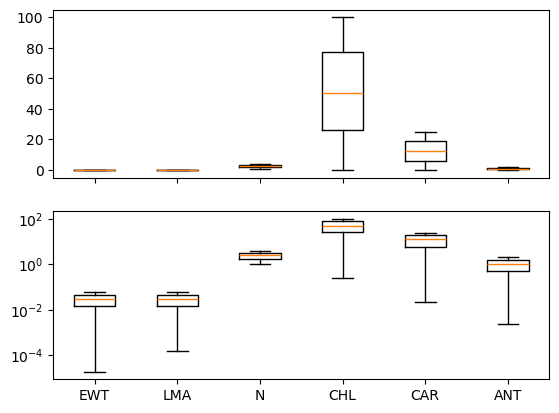

In [4]:
fig_initial = plt.figure()
ax_std = fig_initial.add_subplot(2, 1, 1)
ax_log = fig_initial.add_subplot(2, 1, 2)
ax_std.boxplot(prospect_labels)
ax_log.boxplot(prospect_labels)
ax_log.set_yscale("log")
ax_std.set_xticks(range(1, 7), "")
ax_log.set_xticks(range(1, 7), labels)

In [5]:
prospect_spectra.shape

(1000, 2101)

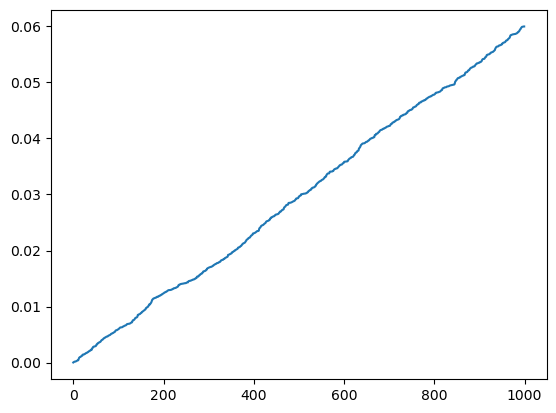

In [6]:
plt.plot(np.sort(prospect_labels[:,0]))

Generate 'all-up' basic model
-----------------------------

In [20]:
vec = tc.vectorizer.PolynomialVectorizer(list(labels[:3]), 2)
vec.get_human_readable_label_vector()

'1 + EWT + LMA + N + EWT^2 + EWT*LMA + EWT*N + LMA^2 + LMA*N + N^2'

In [21]:
# Initialise and train the complete Cannon Model
prospect_model = tc.CannonModel(
    prospect_labels,
    prospect_spectra, prospect_spectra_ivar,
    vectorizer=tc.vectorizer.PolynomialVectorizer(list(labels), 2),dispersion=prospect_wavelength)
prospect_theta, prospect_s2, prospect_metadata = prospect_model.train(threads=1)

2025-10-20 17:14:36,104 [INFO] Training 6-label CannonModel with 1000 input spectra and 2101 pixels/spectrum


[==                                                                                                  ]   3% (55/2101)                          

stty: stdin isn't a terminal


[===                                                                                                 ]   3% (69/2101)                          

2025-10-20 17:14:36,342 [WARNING] Optimization warning (l_bfgs_b): ABNORMAL: 


...

[============================================================================================        ]  92% (1937/2101)                          

2025-10-20 17:14:38,321 [WARNING] Optimization warning (l_bfgs_b): ABNORMAL: 


[=============================================================================================       ]  93% (1954/2101)                          

2025-10-20 17:14:38,347 [WARNING] Optimization warning (l_bfgs_b): ABNORMAL: 


[====================================================================================================] 100% (2s)                                 


What we do here is the basic test step; we take the same spectra that we trained the model with, and see how well it recovers the labels that we know with certainty.

In [ ]:
# Test the label recovery of the same spectra
prospect_test_labels_old, prospect_test_cov_old, prospect_metadata_old = prospect_model.test(prospect_spectra, prospect_spectra_ivar, fit_func=tc.fitting.fit_spectrum_orig)

Automatic pdb calling has been turned OFF


stty: stdin isn't a terminal
2025-10-20 17:14:38,543 [INFO] Running test step on 1000 spectra


[====================================================================================================] 100% (10s)                               


In the plot below, the known input value is along the x-axis, and the recovered value from the test step is on the y-axis. For perfect recovery, all points should lie along the dashed line. The $\mu$ (mean) and $\sigma$ (standard deviation) shown on each plot is for the difference between the reference and training values.

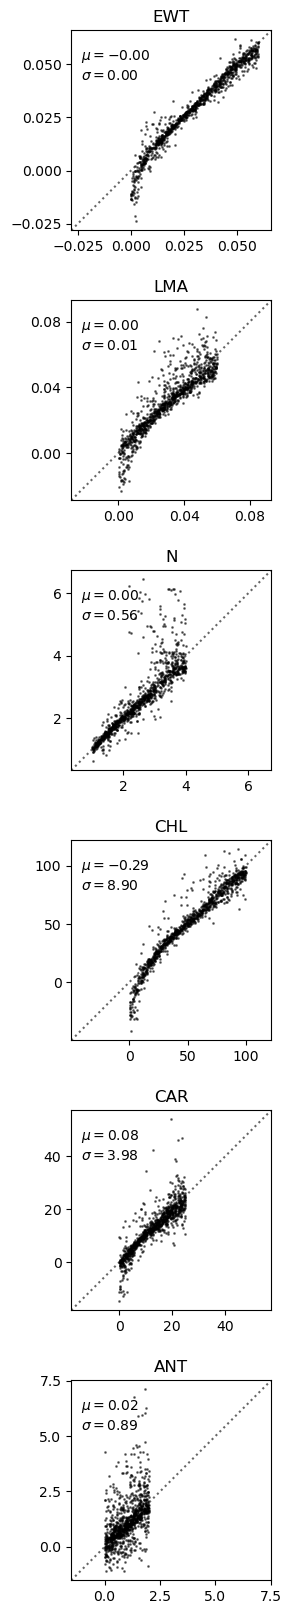

In [23]:
fig_one_to_one = tc.plot.one_to_one(prospect_model, prospect_test_labels_old)

In [24]:
# Test the label recovery of the same spectra
prospect_test_labels_new, prospect_test_cov_new, prospect_metadata_new = prospect_model.test(prospect_spectra, prospect_spectra_ivar, fit_func=tc.fitting.fit_spectrum)

stty: stdin isn't a terminal
2025-10-20 17:15:14,919 [INFO] Running test step on 1000 spectra
2025-10-20 17:15:14,921 [INFO] Using least squares solver method 'lm'.


[                                                                                                    ]   0% (1/1000)                          

2025-10-20 17:15:14,954 [INFO] Using least squares solver method 'lm'.


[                                                                                                    ]   0% (2/1000)                          

2025-10-20 17:15:14,965 [INFO] Using least squares solver method 'lm'.


...

[=================================================================================================== ] 100% (998/1000)                          

2025-10-20 17:15:27,409 [INFO] Using least squares solver method 'lm'.


[=================================================================================================== ] 100% (999/1000)                          

2025-10-20 17:15:27,416 [INFO] Using least squares solver method 'lm'.


[====================================================================================================] 100% (13s)                         


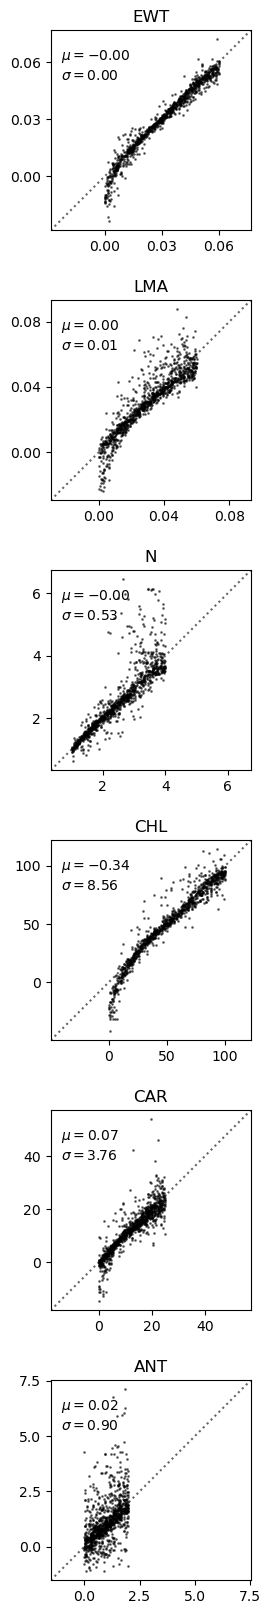

In [25]:
fig_one_to_one = tc.plot.one_to_one(prospect_model, prospect_test_labels_new)

In [29]:
prospect_metadata_new

({'nfev': 273,
  'fvec': array([-1.0569818 , -0.9983661 , -0.95574926, ...,  0.94094132,
          0.97897733,  0.92891417], shape=(2101,)),
  'x0': array([2.95661485e-02, 3.00959241e-02, 2.49383557e+00, 5.06649317e+01,
         1.26779599e+01, 1.00078021e+00]),
  'chi_sq': np.float64(4683.129765753827),
  'ier': 3,
  'mesg': '`xtol` termination condition is satisfied.',
  'model_flux': array([0.04242332, 0.04244261, 0.04245866, ..., 0.03009573, 0.02994733,
         0.03014683], shape=(2101,)),
  'method': 'leastsq',
  'label_names': ['EWT', 'LMA', 'N', 'CHL', 'CAR', 'ANT'],
  'best_result_index': np.int64(0),
  'derivatives_used': True,
  'snr': np.float64(52.364100012671294),
  'r_chi_sq': np.float64(2.2364516550877873),
  'ftol': 2.220446049250313e-16,
  'xtol': 2.220446049250313e-16,
  'gtol': 2.220446049250313e-16,
  'max_nfev': 100000},
 {'nfev': 78,
  'fvec': array([0.3793183 , 0.29519554, 0.21585732, ..., 1.21411269, 1.24086471,
         1.2285955 ], shape=(2101,)),
  'x0': arr

(array([[ 47., 582., 355.,   4.,   0.,   1.,   2.,   9.,   0.,   0.],
        [ 11., 351., 602.,  24.,   0.,   0.,   1.,  11.,   0.,   0.],
        [  0.,  18., 312., 612.,  46.,   0.,   0.,   1.,   5.,   6.],
        [  0.,   2.,  20., 310., 622.,  34.,   0.,   0.,   1.,  11.],
        [  0.,   0.,  19., 455., 487.,  27.,   0.,   0.,   3.,   9.],
        [  0.,   1.,  56., 648., 274.,   9.,   0.,   0.,  11.,   1.]]),
 array([-30.17144758, -26.7422831 , -23.31311863, -19.88395416,
        -16.45478968, -13.02562521,  -9.59646073,  -6.16729626,
         -2.73813179,   0.69103269,   4.12019716]),
 <a list of 6 BarContainer objects>)

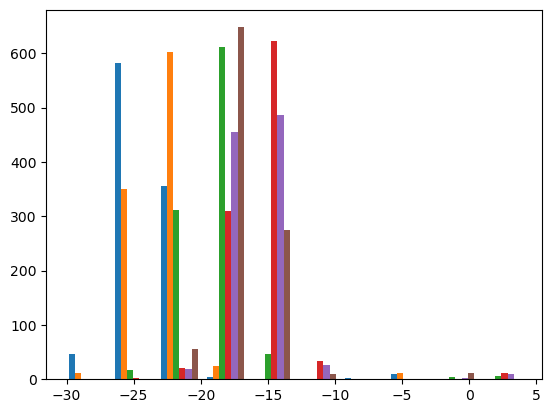

In [26]:
plt.hist(np.log(np.abs(prospect_test_labels_new - prospect_test_labels_old)))

In [31]:
prospect_test_labels_new.shape

(1000, 6)

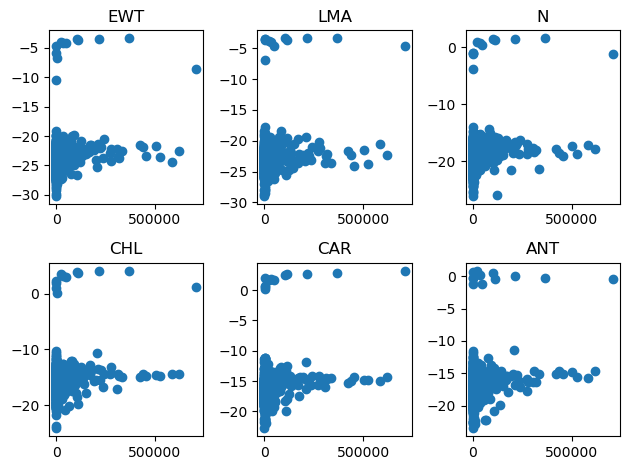

In [40]:
fig = plt.Figure()
for i in range(6):
    ax = fig.add_subplot(2, 3, i+1)
    ax.scatter([_["chi_sq"] for _ in prospect_metadata_new], np.log(np.abs(prospect_test_labels_new[:, i] - prospect_test_labels_old[:, i])))
    ax.set_title(labels[i])
fig.tight_layout()
fig

Generate a model limited to two labels
--------------------------------------

In [11]:
# Initialise and train the restricted Cannon Model
prospect_model_limited = tc.CannonModel(
    prospect_labels_limited,
    prospect_spectra, prospect_spectra_ivar,
    vectorizer=tc.vectorizer.PolynomialVectorizer(list(labels_limited), 2),dispersion=prospect_wavelength)
prospect_theta_limited, prospect_s2_limited, prospect_metadata_limited = prospect_model_limited.train(threads=1)

2025-10-20 17:12:17,827 [INFO] Training 2-label CannonModel with 1000 input spectra and 2101 pixels/spectrum


[========                                                                                            ]   8% (176/2101)                          

stty: stdin isn't a terminal


[====================================================================================================] 100% (2s)                                 


In [12]:
# Test the label recovery of the same spectra
prospect_test_labels_limited, prospect_test_cov_limited, prospect_metadata_limited = prospect_model_limited.test(prospect_spectra, prospect_spectra_ivar)

stty: stdin isn't a terminal
2025-10-20 17:12:20,265 [INFO] Running test step on 1000 spectra
2025-10-20 17:12:20,266 [INFO] Using least squares solver method 'lm'.


[                                                                                                    ]   0% (1/1000)                          

2025-10-20 17:12:20,268 [INFO] Using least squares solver method 'lm'.


[                                                                                                    ]   0% (2/1000)                          

2025-10-20 17:12:20,271 [INFO] Using least squares solver method 'lm'.


...

[=================================================================================================== ] 100% (998/1000)                          

2025-10-20 17:12:22,442 [INFO] Using least squares solver method 'lm'.


[=================================================================================================== ] 100% (999/1000)                          

2025-10-20 17:12:22,444 [INFO] Using least squares solver method 'lm'.


[====================================================================================================] 100% (2s)                         


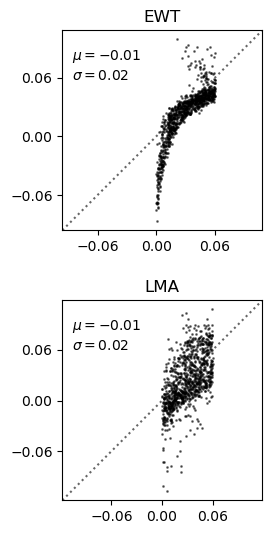

In [13]:
fig_one_to_one_limited = tc.plot.one_to_one(prospect_model_limited, prospect_test_labels_limited)

Run a restricted model
----------------------

So far, we've allowed every label to be completely free in fitting. However, this is unphysical; most of the labels (with the expcetion of `N`) have units weight per unit area, so they have a physical lower limit of 0.

Note that the theta limits in the `RestrictedCannonModel` are limits on the $`\theta`$ coefficient of the model for that term; they do **not** represent physical limits of the label value (a rookie mistake that the developer made for two weeks). Instead, to get limits on the output labels, one needs to send label bounds through to the `test` function.

By not specifying any `theta_bounds`, `RestrictedCannonModel` is equivalent to a standard `CannonModel`.

In [14]:
# Initialise and train the restricted Cannon Model
from thecannon.restricted import RestrictedCannonModel
prospect_model_restricted = RestrictedCannonModel(
    prospect_labels,
    prospect_spectra, prospect_spectra_ivar,
    vectorizer=tc.vectorizer.PolynomialVectorizer(list(labels), 2),dispersion=prospect_wavelength)
# prospect_model_restricted.theta_bounds = {
#     t: (1e-9, None) for t in prospect_model_restricted.vectorizer.human_readable_label_vector.split(" + ")[1:]  # Ignore +1 term
# }
# prospect_model_restricted.theta_bounds["N"] = (1.0, 4.0)

prospect_theta_restricted, prospect_s2_restricted, prospect_metadata_restricted = prospect_model_restricted.train(threads=1)
print(prospect_model_restricted.theta_bounds)

2025-10-20 17:12:22,522 [INFO] Training 6-label RestrictedCannonModel with 1000 input spectra and 2101 pixels/spectrum
stty: stdin isn't a terminal


[===                                                                                                 ]   3% (69/2101)                          

2025-10-20 17:12:22,735 [WARNING] Optimization warning (l_bfgs_b): ABNORMAL: 


[=============                                                                                       ]  14% (290/2101)                          

2025-10-20 17:12:23,044 [WARNING] Optimization warning (l_bfgs_b): ABNORMAL: 


...

[============================================================================================        ]  92% (1937/2101)                          

2025-10-20 17:12:24,653 [WARNING] Optimization warning (l_bfgs_b): ABNORMAL: 


[=============================================================================================       ]  93% (1954/2101)                          

2025-10-20 17:12:24,672 [WARNING] Optimization warning (l_bfgs_b): ABNORMAL: 


[====================================================================================================] 100% (2s)                                 
{}


In [15]:
# %pdb
# Test the label recovery of the same spectra
bnds = ([-1 for l in prospect_model_restricted.vectorizer.label_names], [1000.0 for l in prospect_model_restricted.vectorizer.label_names])
prospect_test_labels_restricted, prospect_test_cov_restricted, prospect_metadata_restricted = prospect_model_restricted.test(
    prospect_spectra, prospect_spectra_ivar, 
    initial_labels=[0.01] * 6,
    op_kwds={"bounds": Bounds(
        lb=[0.0 for label in prospect_model_restricted.vectorizer.label_names], 
        ub=[4.0 if label == "N" else np.inf for label in prospect_model_restricted.vectorizer.label_names], 
        keep_feasible=[False for label in prospect_model_restricted.vectorizer.label_names])}
    )

stty: stdin isn't a terminal
2025-10-20 17:12:24,853 [INFO] Running test step on 1000 spectra
2025-10-20 17:12:24,854 [INFO] Using least squares solver method 'trf'.


[                                                                                                    ]   0% (1/1000)                          

2025-10-20 17:12:24,893 [INFO] Using least squares solver method 'trf'.


[                                                                                                    ]   0% (2/1000)                          

2025-10-20 17:12:24,920 [INFO] Using least squares solver method 'trf'.


...

[=================================================================================================== ] 100% (998/1000)                          

2025-10-20 17:12:40,698 [INFO] Using least squares solver method 'trf'.


[=================================================================================================== ] 100% (999/1000)                          

2025-10-20 17:12:40,711 [INFO] Using least squares solver method 'trf'.


[====================================================================================================] 100% (16s)                         


In [16]:
for i in range(prospect_test_labels_restricted.shape[1]):
    print(f"{i}: {np.min(prospect_test_labels_restricted[:, i])}, {np.max(prospect_test_labels_restricted[:, i])}")

0: 1.0408340855860843e-17, 0.0696362827361838
1: 3.469446951953614e-18, 0.09681604500245024
2: 0.7547091360432265, 4.0
3: 7.105427357601002e-15, 118.49151533469194
4: 1.7763568394002505e-15, 52.38703175929081
5: 2.220446049250313e-16, 4.751321280263372


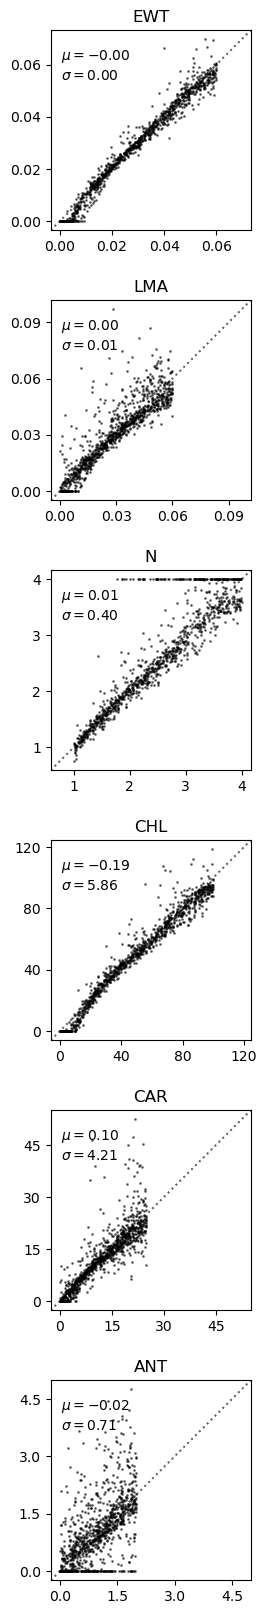

In [17]:
fig_one_to_one_restricted = tc.plot.one_to_one(prospect_model_restricted, prospect_test_labels_restricted)